# 04 - Friction

## Purpose

This notebook continues a series working toward an accurate, mathematically
proven servo control loop, built on empirical data. Notebook 00
characterized the measurement chain, notebook 01 the four bridge states and
the coast spin-down. This notebook measures the friction of the mechanism,
from the voltage that first moves it to the way it comes to rest.

The friction model is Coulomb plus viscous,

$$\tau_f = \tau_c\,\mathrm{sign}(\omega) + b_v\,\omega,$$

with $\tau_c$ the Coulomb torque and $b_v$ the viscous coefficient. Two
independent routes measure it in different units. In coast (route A) the
deceleration is $a + b\,v$ with $a = \tau_c / J$ and $b = b_v / J$. Under
drive at steady speed (route B) the motor current balances the friction,
$K_t\,i = \tau_c + b_v\,\omega$, so the steady-state current against speed
is a line $i = i_c + i_v\,\omega$ with $i_c = \tau_c / K_t$ and
$i_v = b_v / K_t$. Neither $J$ nor $K_t$ is known here, and the ratio
$\tau_c / b_v$ cancels both. It equals $a / b$ from route A and
$i_c / i_v$ from route B, and both are a speed, the speed at which viscous
friction equals Coulomb friction. Agreement of the two ratios is the test
this notebook is built around.

This notebook has three jobs:

1. Measure the breakaway duty and voltage per direction (section 5).
2. Measure the friction constants by both routes and test the ratio
   (sections 6 and 7).
3. Examine the approach to rest and the dependence of friction on position
   (section 8).

The dataset is three test series from one session on a laptop USB port, all
captured on the current measurement chain (chain 3 in notebook 00), and
described in section 3. An earlier run of all three on a 2-cell battery and
the previous chain is retired and is not a fit input anywhere below. Both
the chain and the supply changed between the two runs, so where an old
number is quoted for comparison I say which of the two could have moved
it.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01 (chain 3). The points this notebook
depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts and speed in wiper volts per second. The pot-derived speed
  carries a ripple of 20 to 30% with a period of 0.1 to 0.2 wiper V
  (notebook 01, section 6.1), so every speed estimate below states the
  window it averages over.
- A 60 mOhm shunt in the motor return path, amplified with gain 15.0, gives
  the motor current. The crest scan samples it at the center of the drive
  window. The amplifier output includes an offset, measured from the
  baseline segment of each recording and subtracted throughout.
- Both motor terminals are read through 6.8 kOhm / 3.3 kOhm dividers whose
  bottom legs return to a common bias node $V_B$ of about 0.63 V, each tap
  with a 150 pF reservoir capacitor, so both terminals stay readable during
  coast and their difference reads the back-EMF free of the bias (notebook
  01, sections 2 and 6.1). That difference is the direct speed signal
  route A uses.
- The ADC is clocked at 48 MHz, which is what brought the voltage sampling
  floor down to 10% duty (section 2). That matters here, because the
  breakaway ramp now reaches above it.

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (notebook 00, section 5.2, bins the rest
current by position inside the frame and finds it flat within a count),
but one count is 0.9 mA on this chain, so a few counts is a few
milliamps, and route B's whole line lives between 35 and 100 mA. A few
milliamps there is a few percent of $i_c$. It is a known limitation of
this board, and I do not code around it anywhere in this notebook.

Power is a laptop USB port. The rail reaching the motor is measured at the
driven terminal in section 5.2. It is about 4.55 V at the gentle duties the
breakaway voltage is scaled by, well below the nominal 5 V, and it sags
further under load. The retired battery run sat at 7.35 V, flat, so every
speed, every voltage and every current in this notebook is smaller than in
that run for the supply alone, before any chain difference.

## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
per chain, the same table as notebooks 00 and 01. The shunt, the divider
legs, the amplifier gain, and VDD are written into every recording's
`meta.json` by the capture tool (the `sense` block), and the loader in
section 3 checks each recording against this table and against the supply,
and stops with an error if they disagree. The bias divider, the reservoir
capacitor, and the sampling floors are not in the metadata, so this table
is the only record of them. Every recording in this notebook is on chain 3.
Chain 2 stays in the table as the record of what the retired battery run
was captured on.

| Quantity | Chain 3 (this dataset) | Chain 2 (retired battery run) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording and per terminal, from the segment-0 baseline (section 3) | per recording |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |
| Winding resistance $R$ | 4.5 Ohm, bracket 4.3 to 4.8, input from notebook 03 | 4.3 Ohm on that chain |

A drive-window current sample is settled for duty at or above 13.3% and a
drive-window voltage sample for duty at or above 10.0% (notebook 01,
section 2). The streamed `window_valid` flag encodes the current floor.
The breakaway ramp of section 5 now runs to 18% duty, so its top rungs sit
above both floors, but the onset itself lands below the current floor and
its current is still shown rather than fitted.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

The divider ratio $r$ is 3.06 on chain 3 and exactly 3 on chain 2. On
chain 3 the two taps do not read the same bias at rest. They differ by 18
to 19 counts in every recording of every series, and notebook 00 (section
5.3) leaves the cause open. So every absolute terminal voltage below uses
the second form with the rest reading of its own terminal in its own
recording, which absorbs the split as an offset, and the difference
$v_A - v_B$ then reads zero at rest.

The winding resistance enters once, in section 5.3, to turn the breakaway
voltage into a model-derived current. It is an input from notebook 03,
which is being re-run on chain 3 as I write this, so I carry its bracket
of 4.3 to 4.8 Ohm through that calculation rather than one number.

Two caveats carry over. The ADC reference is the design value, so every
voltage scales with the true VDD of this unit. The divider, shunt and gain
are design values with unmeasured tolerances.

The derived conversion factors, per chain:

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares, curve_fit

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on, and the supply it ran on
CAMPAIGN_CHAIN = {"breakaway-usb": 3, "bridge-usb": 3, "usb": 3}
SUPPLY = "usb"

# winding resistance, the one input from notebook 03 (chain 3, USB session)
R_WINDING_OHM = 4.5         # full-duty onset anchor
R_WINDING_LO, R_WINDING_HI = 4.3, 4.8   # its bracket

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")
        if meta["supply"] != SUPPLY:
            raise ValueError(f"{where}: supply {meta['supply']!r}, expected {SUPPLY!r}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}
CH = CHAINS[CAMPAIGN_CHAIN["breakaway-usb"]]   # every number in this notebook is on this chain

def term_V(tap_counts, vb_counts):
    # Shorthand for the chain of this notebook.
    return CH.term_V(tap_counts, vb_counts)

rows = []
for ch in CHAINS.values():
    rows += [
        {"chain": ch.label, "quantity": "pot wiper", "value": ch.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal divider ratio r", "value": ch.div_ratio, "unit": ""},
        {"chain": ch.label, "quantity": "motor terminal difference", "value": ch.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": ch.label, "quantity": "motor current", "value": ch.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": ch.label, "quantity": "drive window settled, current", "value": ch.floor_i_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "drive window settled, voltage", "value": ch.floor_v_pct, "unit": "% duty and above"},
    ]
rows.append({"chain": CH.label, "quantity": "winding resistance (input)", "value": R_WINDING_OHM, "unit": "Ohm"})
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)

,chain,"chain 2, retired",chain 3
quantity,unit,,
"drive window settled, current",% duty and above,13.3333,13.3333
"drive window settled, voltage",% duty and above,17.5000,10.0000
motor current,mA per count,1.6276,0.8952
motor terminal difference,mV per count,2.4170,2.4658
pot wiper,mV per count,0.8057,0.8057
"terminal bias, nominal",mV,622.6415,627.9352
terminal divider ratio r,,3.0000,3.0606
winding resistance (input),Ohm,NaN,4.5000


## 3. Capture method

Three test series enter, all under slow decay on the same USB supply in one
session, all under `notebooks/telemetry/sg90/`, one folder per recording.
Every recording starts with a one-second baseline segment with the bridge
disabled, which gives the current offset, the rest reading of each terminal
and the position noise floor.

- **Ramp** (`breakaway-usb/`, five recordings). After the baseline, 200 ms
  drive steps at 1%, 2%, ... 18% duty, first forward (segments 1 to 18)
  then reverse (segments 19 to 36). The ladder runs to 18% because at
  4.5 V the mechanism does not break away until 9% or higher, where the
  old 12-rung ladder on the battery barely reached the onset. The first
  milliseconds of every step carry residual motion from the repositioning
  move, and the 1% steps carry little else. Motion is therefore judged
  from the last 100 ms of each step, never from total travel.
- **Spin-down** (`bridge-usb/`, five recordings, the spin-down sweep of
  notebook 01). For 20%, 30% and 40% duty in turn, an 80 ms drive step
  followed by 400 ms of coast, then a second drive step at the same duty
  followed by 400 ms of brake, forward then reverse, 24 segments. The
  coast segments are route A's data.
- **Grid** (`usb/`, ten recordings). 80 ms drive steps at 5% to 100% in 5%
  increments, forward then reverse, 40 segments. The steady state at the
  end of each step is route B's data. The steps do not settle within
  80 ms, which section 6.1 measures and corrects.

Before every drive step of every series the servo is repositioned at 15%
duty toward the far end of travel, so the step has room to run. The
mechanism can still be moving from that repositioning move when the step
begins, in the direction opposite to the step.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down metadata lists the schedule, from which the
kind of every zero-duty segment (coast or brake) follows.

The segment-0 baseline of every recording gives three per-recording
constants, the shunt amplifier's bias (mean of `current_raw`) and the rest
reading of each terminal (median of `vmotor_a` and of `vmotor_b`), which
are the $V_B$ of terminal A and of terminal B in the tap formula. The
loader also checks each recording's `sense` block and supply against
section 2. The table summarizes all three per series.

In [2]:
TELEMETRY = Path("telemetry/sg90")

def load_sweep(rec_dir, stem):
    # One sweep = <stem>.csv.gz (per-tick samples) + its meta.json. Derived
    # columns: duty_pct (signed percent), mag_pct (rounded magnitude), and the
    # per-recording baseline constants bias (shunt amplifier offset), vb
    # (terminal A rest reading), vb_b (terminal B rest reading).
    df = pd.read_csv(rec_dir / f"{stem}.csv.gz")
    meta_name = "meta.json" if stem == "sweep" else f"{stem}.meta.json"
    meta = json.loads((rec_dir / meta_name).read_text())
    CH.check_meta(meta, f"{rec_dir}/{stem}")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if stem == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def load_series(base, stem):
    recs = {}
    for d in sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
        recs[d.name] = load_sweep(d, stem)
    return recs

ramp = load_series(TELEMETRY / "breakaway-usb", "sweep")
spin = load_series(TELEMETRY / "bridge-usb", "spindown")
grid = load_series(TELEMETRY / "usb", "sweep")

RAMP_MAX_PCT = max(ramp[next(iter(ramp))][0]["mag_pct"])   # top rung of the ramp ladder

rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    bias = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    first = next(iter(recs.values()))
    rows.append({
        "series": series,
        "recordings": len(recs),
        "segments per recording": first[0]["seg"].nunique(),
        "drive step [ms]": first[1]["window_ms"],
        "VB_A [counts], min": vb.min(), "VB_A [counts], max": vb.max(),
        "VB_B [counts], min": vb_b.min(), "VB_B [counts], max": vb_b.max(),
        "VB_A [V], mean": vb.mean() * CH.v_adc_per_count,
        "VB_A minus nominal [mV]": (vb.mean() * CH.v_adc_per_count - CH.vb_nom_v) * 1e3,
        "terminal B minus A at rest [counts]": np.median(vb_b - vb),
        "shunt bias [counts], min": bias.min(), "shunt bias [counts], max": bias.max(),
    })
pd.DataFrame(rows).set_index("series").round(3).T

series,ramp,spin-down,grid
recordings,5.000,5.000,10.000
segments per recording,37.000,25.000,41.000
drive step [ms],200.000,80.000,80.000
"VB_A [counts], min",765.000,766.000,766.000
"VB_A [counts], max",765.000,766.000,766.000
"VB_B [counts], min",784.000,784.000,784.000
"VB_B [counts], max",784.000,784.000,784.000
"VB_A [V], mean",0.616,0.617,0.617
VB_A minus nominal [mV],-11.602,-10.797,-10.797
terminal B minus A at rest [counts],19.000,18.000,18.000


Terminal A rests at 765 or 766 counts and terminal B at 784, a split of 18
to 19 counts that is the same in all twenty recordings of the three series.
Terminal A sits about 11 mV below the nominal bias. The shunt amplifier's
offset is 108 to 113 counts.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.

In [3]:
rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
integ = pd.DataFrame(rows)
integ.groupby("series")[["samples", "segments", "missing_samples"]].agg(["min", "max"])


samples         segments     missing_samples    
              min     max      min max             min max
series                                                    
grid        84000   84000       41  41               0   0
ramp       164000  164000       37  37               0   0
spin-down  135200  135200       25  25               0   0

Every recording of every series has zero missing samples. The ramp holds
164,000 samples in 37 segments, the spin-down 135,200 in 25, and the grid
84,000 in 41.

## 5. Breakaway

### 5.1 Motion onset per direction

For every ramp step the speed is the slope of a least-squares line through
the position of the last 100 ms of the 200 ms step, signed along the
commanded direction. The same slope over the first 100 ms shows the
residual motion from the repositioning move. The motion threshold is five
times the largest 100 ms slope found in the settled baselines of all ramp
and grid recordings (the first 200 ms of each baseline are dropped, since
the mechanism is still coming to rest from the initial move).

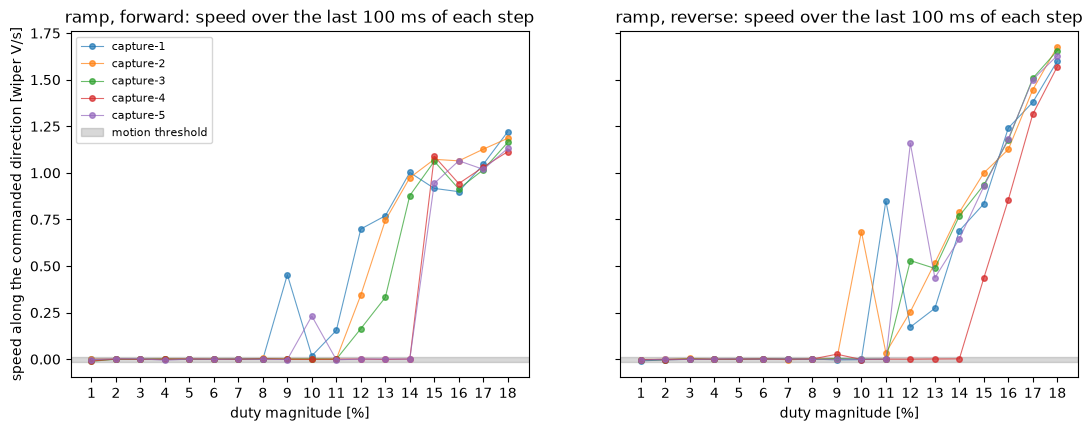

highest still [%]  lowest moving [%]  \
direction recording                                         
forward   capture-1                  8                  9   
          capture-2                 11                 12   
          capture-3                 11                 12   
          capture-4                 14                 15   
          capture-5                 14                 10   
reverse   capture-1                 10                 11   
          capture-2                  9                 10   
          capture-3                 11                 12   
          capture-4                 14                  9   
          capture-5                 11                 12   

                     all moving from [%]  speed at 8% [wiper V/s]  \
direction recording                                                 
forward   capture-1                    9                    0.000   
          capture-2                   12                    0.004   
          capture-3                   12                    0.002   
          capture-4                   15                    0.001   
          capture-5                   15                   -0.000   
reverse   capture-1                   11                    0.001   
          capture-2                   10                    0.002   
          capture-3                   12                   -0.001   
          capture-4                   15                    0.001   
          capture-5                   12                   -0.000   

                     speed at 12% [wiper V/s]  speed at 15% [wiper V/s]  
direction recording                                                      
forward   capture-1                     0.699                     0.917  
          capture-2                     0.344                     1.073  
          capture-3                     0.164                     1.062  
          capture-4                     0.001                     1.089  
          capture-5                     0.000                     0.944  
reverse   capture-1                     0.172                     0.834  
          capture-2                     0.255                     1.000  
          capture-3                     0.529                     0.936  
          capture-4                    -0.000                     0.436  
          capture-5                     1.158                     0.927

In [4]:
WIN_100MS = 2000   # samples in the 100 ms judgment window
SPEED_AT = (8, 12, 15)  # duty points quoted in the onset table

def baseline_slope_max(recs_list):
    # Largest |slope| over 100 ms windows of the settled baselines.
    worst = 0.0
    for recs in recs_list:
        for df, _ in recs.values():
            base = df[df["seg"] == 0]["pos"].to_numpy() * CH.v_adc_per_count
            base = base[len(base) // 5:]
            for k in range(0, len(base) - WIN_100MS, WIN_100MS):
                w = base[k:k + WIN_100MS]
                worst = max(worst, abs(np.polyfit(np.arange(WIN_100MS) / TICK_HZ, w, 1)[0]))
    return worst

MOTION_VPS = 5 * baseline_slope_max([ramp, grid])

def ramp_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        p = seg["pos"].to_numpy() * CH.v_adc_per_count
        t = np.arange(WIN_100MS) / TICK_HZ
        # the driven terminal of a step, read with that terminal's own rest reading
        hi, vb = ("vmotor_a", seg["vb"].iloc[0]) if d > 0 else ("vmotor_b", seg["vb_b"].iloc[0])
        out.append({
            "mag_pct": int(round(abs(d))),
            "dir": int(s),
            "head_Vps": np.polyfit(t, p[:WIN_100MS], 1)[0] * s,
            "tail_Vps": np.polyfit(t, p[-WIN_100MS:], 1)[0] * s,
            "current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * CH.a_per_count,
            "valid_frac": seg["window_valid"].mean(),
            "driven_terminal_V": term_V(seg[hi].median(), vb),
        })
    return pd.DataFrame(out)

ramp_tab = pd.concat([ramp_steps(df).assign(recording=n) for n, (df, _) in ramp.items()])
ramp_tab["moving"] = ramp_tab["tail_Vps"] > MOTION_VPS

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, d, label in [(axes[0], 1, "forward"), (axes[1], -1, "reverse")]:
    for name, g in ramp_tab[ramp_tab["dir"] == d].groupby("recording"):
        ax.plot(g["mag_pct"], g["tail_Vps"], "-o", ms=4, lw=0.8, alpha=0.7, label=name)
    ax.axhspan(-MOTION_VPS, MOTION_VPS, color="grey", alpha=0.3, label="motion threshold")
    ax.set_xlabel("duty magnitude [%]")
    ax.set_title(f"ramp, {label}: speed over the last 100 ms of each step")
    ax.set_xticks(range(1, RAMP_MAX_PCT + 1))
axes[0].set_ylabel("speed along the commanded direction [wiper V/s]")
axes[0].legend(fontsize=8)
plt.show()

rows = []
for (name, d), g in ramp_tab.groupby(["recording", "dir"]):
    row = {
        "recording": name,
        "direction": "forward" if d > 0 else "reverse",
        "highest still [%]": g[~g["moving"]]["mag_pct"].max(),
        "lowest moving [%]": g[g["moving"]]["mag_pct"].min(),
        "all moving from [%]": min(m for m in g["mag_pct"] if (g[g["mag_pct"] >= m]["moving"]).all()),
    }
    for pct in SPEED_AT:
        row[f"speed at {pct}% [wiper V/s]"] = g[g["mag_pct"] == pct]["tail_Vps"].iloc[0]
    rows.append(row)
onset = pd.DataFrame(rows).set_index(["direction", "recording"]).sort_index()
onset.round(3)

In [5]:
# Motion threshold, movers per grid point, and the residual motion of the
# first 100 ms against the last 100 ms, pooled over recordings.
BAND = RAMP_MAX_PCT   # the whole ladder
movers = (ramp_tab[ramp_tab["mag_pct"] <= BAND].groupby(["dir", "mag_pct"])["moving"]
          .sum().unstack(0).rename(columns={1: "forward movers of 5", -1: "reverse movers of 5"}))
speeds = (ramp_tab[ramp_tab["mag_pct"] <= BAND].groupby(["dir", "mag_pct"])[["head_Vps", "tail_Vps"]]
          .mean().unstack(0))
speeds.columns = [f"{a} {'forward' if b > 0 else 'reverse'}" for a, b in speeds.columns]
out = pd.concat([movers, speeds], axis=1).round(3)
out.index.name = f"duty [%]  (threshold {MOTION_VPS:.3f} wiper V/s)"
out

,reverse movers of 5,forward movers of 5,head_Vps reverse,head_Vps forward,tail_Vps reverse,tail_Vps forward
duty [%] (threshold 0.014 wiper V/s),,,,,,
1,0,0,-0.075,-0.037,-0.004,-0.005
2,0,0,-0.000,0.001,-0.002,0.000
3,0,0,-0.001,-0.000,0.001,0.000
4,0,0,0.000,0.001,-0.000,-0.001
5,0,0,0.002,0.001,0.000,0.000
6,0,0,0.003,-0.000,0.001,-0.000
7,0,0,0.001,0.000,-0.000,0.000
8,0,0,-0.001,0.011,0.000,0.002
9,1,1,0.022,0.048,0.006,0.090


Findings:

- The threshold is 0.014 wiper V/s, a third of the 0.050 the battery
  session gave. The mechanism settles faster on the weaker supply, so the
  baselines are quieter and the test is stricter.
- Every step at 8% and below sits inside the threshold in the last 100 ms,
  in both directions, in all five recordings. The 1% steps show the
  residual motion of the repositioning move in their first 100 ms, 0.04 to
  0.08 wiper V/s opposite to the command on average, and nothing in their
  last 100 ms.
- The first movers are at 9%, one recording of five in each direction. The
  count climbs unevenly through 10 to 14%, and at 15% and above all five
  recordings move in both directions. The speed of a moving 12% step is
  0.16 to 1.16 wiper V/s and of a 15% step 0.44 to 1.09, so a step either
  breaks away within its 200 ms or does not.
- Recordings 4 and 5 are the stiff ones. Both sat still up to 14% forward,
  where recording 1 broke away at 9%. The five recordings run back to back
  in one session, so the trend with recording number is real, but this
  design cannot say whether it is warm-up, wear from the repositioning
  moves, or where the mechanism happened to be parked.

The motion onset of this unit lies between 8% and 15% duty in both
directions, with 9% to 14% marginal. The two directions come out with the
same numbers on this ladder, so the direction asymmetry the battery run
hinted at is not there.

### 5.2 Breakaway voltage

The supply rail comes from the grid recordings, as the median driven
terminal over the valid 20% to 30% steps, the gentlest settled steps, in
corrected terminal volts. Each direction is read on its own terminal with
that terminal's own rest reading. The ramp's own driven terminal above the
10% voltage floor is shown next to it, which this ladder can do for the
first time. The breakaway voltage is the onset duty times the rail.

In [6]:
def rail_V(df, lo, hi):
    # Supply rail: median driven terminal over the valid drive steps in the
    # duty range, each direction read on its own terminal with that
    # terminal's own rest reading, then averaged.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1)
           & (df["mag_pct"] >= lo) & (df["mag_pct"] <= hi)]
    vals = []
    for sel, col, vb in ((v["duty_pct"] > 0, "vmotor_a", "vb"), (v["duty_pct"] < 0, "vmotor_b", "vb_b")):
        if sel.any():
            vals.append(term_V(np.median(v.loc[sel, col]), df[vb].iloc[0]))
    return float(np.mean(vals))

grid_rails = pd.Series({n: rail_V(df, 20, 30) for n, (df, _) in grid.items()})
RAIL_V = grid_rails.mean()
# the ramp's own driven terminal, over the rungs above the voltage floor
ramp_term = ramp_tab[(ramp_tab["dir"] > 0) & (ramp_tab["mag_pct"] > CH.floor_v_pct)]["driven_terminal_V"]

rows = []
for label in ["forward", "reverse"]:
    o = onset.loc[label]
    still = int(o["highest still [%]"].max())
    low = int(o["lowest moving [%]"].min())
    high = int(o["all moving from [%]"].max())
    rows.append({
        "direction": label,
        "highest still in any recording [%]": still,
        "moving from [%], marginal": low,
        "moving from [%], every recording": high,
        "highest still in any recording [V]": still / 100 * RAIL_V,
        "breakaway low [V]": low / 100 * RAIL_V,
        "breakaway high [V]": high / 100 * RAIL_V,
    })
break_tab = pd.DataFrame(rows).set_index("direction")
break_tab.insert(0, "rail from grid [V]", RAIL_V)
break_tab.insert(1, "rail spread over recordings [V]", grid_rails.max() - grid_rails.min())
break_tab.insert(2, f"ramp terminal above {CH.floor_v_pct:.0f}% forward [V]", ramp_term.mean())
break_tab.round(3).T

direction,forward,reverse
rail from grid [V],4.548,4.548
rail spread over recordings [V],0.036,0.036
ramp terminal above 10% forward [V],4.611,4.611
highest still in any recording [%],14.000,14.000
"moving from [%], marginal",9.000,9.000
"moving from [%], every recording",15.000,15.000
highest still in any recording [V],0.637,0.637
breakaway low [V],0.409,0.409
breakaway high [V],0.682,0.682


The rail is 4.55 V with a spread of 0.036 V across the ten grid
recordings, and the ramp's forward driven terminal above 10% duty reads
4.61 V, 0.06 V higher, because the ramp draws less current than the 20 to
30% grid steps and the USB supply sags less. On the battery the two agreed
to 0.01 V, since that supply held its rail flat. I use the grid rail, so
the breakaway voltages below are if anything 1% low.

The breakaway voltage band is 0.41 to 0.68 V, the same in both directions.
The highest duty that sat still in any recording is 14% (0.64 V), and
0.36 V (8%) never moved in either direction. The band is wider than the
0.37 to 0.51 V the battery run gave, and most of that width is the
recording-to-recording spread of section 5.1 rather than a coarse ladder.
The lower edge agrees with the old one within 10%.

### 5.3 The current at the onset

The crest-scan current of every ramp step is shown below, bias subtracted.
The rungs inside the grey band are under the 13.3% current floor, so they
are unsettled amplifier outputs and no quantity is fitted on them. From
14% up the samples are settled, which this ladder reaches and the old one
did not. There the ramp reads 35 to 49 mA at 14%, where some recordings
are still stalled and some are moving, and 40 mA with a 1 mA spread at
18%, where all of them move. That is the same 30 to 40 mA that route B's
Coulomb intercept gives in section 6.1. It is well under what the rail and
the winding resistance would predict for a stalled motor, which is the
same tension notebook 03 runs into on its own drive-side current, and this
notebook does not settle it.

The breakaway current itself still has to be model-derived, as the
breakaway voltage divided by the winding resistance, which assumes the
motor is at rest with no back-EMF at the moment of breakaway. The onset
sits at 9 to 15% duty and the current floor at 13.3%, so most of the band
is still below it. The resistance is notebook 03's input, and the spread
column carries its 4.3 to 4.8 Ohm bracket.

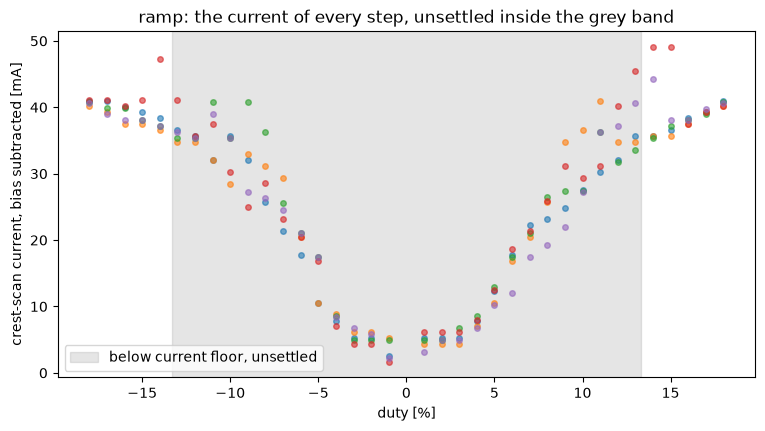

,value,spread,source
quantity,,,
unsettled crest current at 1% [mA],1.673,4.476,"ramp, both directions"
unsettled crest current at 13% [mA],33.583,11.953,"ramp, both directions"
settled crest current at 14% [mA],35.374,13.743,"ramp, above the current floor"
settled crest current at 18% [mA],40.125,0.935,"ramp, above the current floor"
winding resistance [Ohm],4.500,0.500,"notebook 03, full-duty anchor (input)"
"breakaway current, forward, low [A], model-derived",0.091,0.010,breakaway voltage / R
"breakaway current, forward, high [A], model-derived",0.152,0.017,breakaway voltage / R
"breakaway current, reverse, low [A], model-derived",0.091,0.010,breakaway voltage / R
"breakaway current, reverse, high [A], model-derived",0.152,0.017,breakaway voltage / R


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, g in ramp_tab.groupby("recording"):
    ax.plot(g["mag_pct"] * g["dir"], g["current_A"] * 1e3, "o", ms=4, alpha=0.6)
ax.axvspan(-CH.floor_i_pct, CH.floor_i_pct, color="grey", alpha=0.2, label="below current floor, unsettled")
ax.set_xlabel("duty [%]")
ax.set_ylabel("crest-scan current, bias subtracted [mA]")
ax.set_title("ramp: the current of every step, unsettled inside the grey band")
ax.legend()
plt.show()

cur = ramp_tab.groupby("mag_pct")["current_A"].agg(["min", "max"]) * 1e3
settled_lo = int(np.ceil(CH.floor_i_pct))
rows = [
    {"quantity": "unsettled crest current at 1% [mA]", "value": cur.loc[1, "min"],
     "spread": cur.loc[1, "max"] - cur.loc[1, "min"], "source": "ramp, both directions"},
    {"quantity": f"unsettled crest current at {settled_lo - 1}% [mA]", "value": cur.loc[settled_lo - 1, "min"],
     "spread": cur.loc[settled_lo - 1, "max"] - cur.loc[settled_lo - 1, "min"], "source": "ramp, both directions"},
    {"quantity": f"settled crest current at {settled_lo}% [mA]", "value": cur.loc[settled_lo, "min"],
     "spread": cur.loc[settled_lo, "max"] - cur.loc[settled_lo, "min"], "source": "ramp, above the current floor"},
    {"quantity": f"settled crest current at {RAMP_MAX_PCT}% [mA]", "value": cur.loc[RAMP_MAX_PCT, "min"],
     "spread": cur.loc[RAMP_MAX_PCT, "max"] - cur.loc[RAMP_MAX_PCT, "min"], "source": "ramp, above the current floor"},
    {"quantity": "winding resistance [Ohm]", "value": R_WINDING_OHM,
     "spread": R_WINDING_HI - R_WINDING_LO, "source": "notebook 03, full-duty anchor (input)"},
]
for label in ["forward", "reverse"]:
    rows.append({"quantity": f"breakaway current, {label}, low [A], model-derived",
                 "value": break_tab.loc[label, "breakaway low [V]"] / R_WINDING_OHM,
                 "spread": break_tab.loc[label, "breakaway low [V]"] * (1 / R_WINDING_LO - 1 / R_WINDING_HI),
                 "source": "breakaway voltage / R"})
    rows.append({"quantity": f"breakaway current, {label}, high [A], model-derived",
                 "value": break_tab.loc[label, "breakaway high [V]"] / R_WINDING_OHM,
                 "spread": break_tab.loc[label, "breakaway high [V]"] * (1 / R_WINDING_LO - 1 / R_WINDING_HI),
                 "source": "breakaway voltage / R"})
pd.DataFrame(rows).set_index("quantity").round(3)

With 4.5 Ohm the breakaway current is 0.091 to 0.152 A, model-derived, and
the resistance bracket moves each end by about 0.01 A. Section 6.1 finds
the Coulomb intercept of the drive current at 0.032 to 0.033 A, so the
current at breakaway exceeds the Coulomb current at speed by a factor of
three to five, where the battery run put that factor at two to three.
*Hypothesis (not tested here): static friction exceeds kinetic friction in
this gear train, as is usual for lubricated metal and plastic contacts.
The settled rungs at 14 to 18% now give a real current just above
breakaway, and a finer ladder from 13% to 16% would put a measured number
on the step down from static to kinetic without the resistance in the
way.*

## 6. Friction at speed

### 6.1 Route B, steady-state current against speed

For every grid step at or above the 15% grid point (the first above the
current floor) two quantities are needed, the steady speed and the steady
current. The reference estimate of each follows notebook 00 and uses the
last 60% of the step (48 ms). The speed is the slope of a line through
the position, and the current is the median of the crest-scan samples.

The steps do not settle in 80 ms. The current trace shows it without
ripple. After the first 10 ms it follows a single exponential toward a
floor, with a time constant of 18 to 25 ms in every step of every
recording. That is the mechanical time constant under drive, and 80 ms is
about four of them. Each step is therefore fitted with

$$i(t) = i_{ss} + A\,e^{-t/\tau},$$

which gives the steady current $i_{ss}$ by extrapolation and $\tau$ as a
quality flag. The speed uses the same mode. With $\tau$ fixed from the
current fit, the position over the same window is fitted with

$$p(t) = p_0 + v_{ss}\,t - (v_{ss} - v_0)\,\tau\,(1 - e^{-t/\tau}),$$

linear in $(p_0, v_{ss}, v_0)$, which averages the pot ripple over the
whole 70 ms window. Two quality flags follow from the fit, the remaining
transient in the reference window (how far the last-60% current sits
above the extrapolated steady value) and the residual acceleration at the
end of the step, $(v_{ss} - v_0)\,e^{-T/\tau} / \tau$ with $T$ the 70 ms
fit window, which is the acceleration the mechanism still had when the
step ended.

Route A's coast segments enter at speeds up to about 4.6 wiper V/s
(section 6.2), half what they reached on the battery. The like-for-like
comparison of section 7 therefore fits route B on steps whose steady speed
lies at or below 5.0 wiper V/s (the matched range). The fit is repeated on
an extended range up to 7.0 and on the full range, to show how the line
depends on the range.

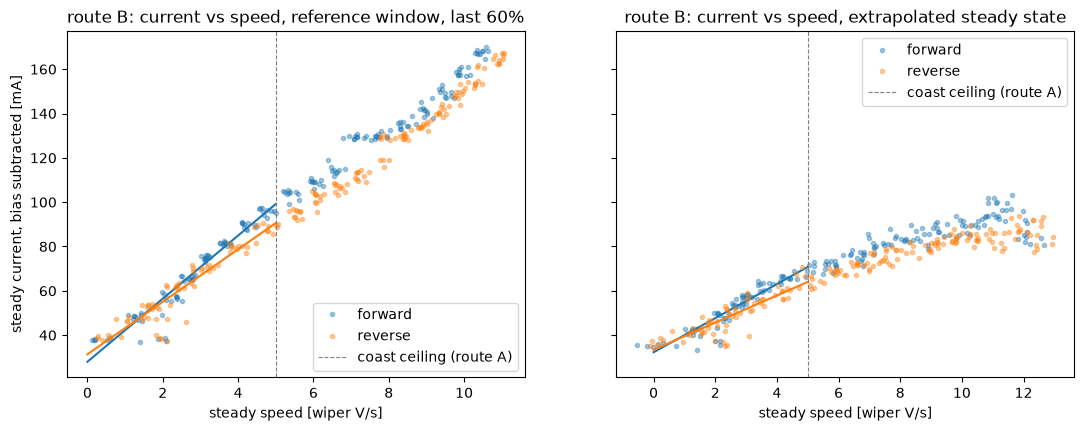

i_c [A]  \
method                     range            direction            
reference window, last 60% matched, <= 5.0  forward     0.0280   
                           extended, <= 7.0 forward     0.0300   
                           full             forward     0.0324   
                           matched, <= 5.0  reverse     0.0314   
                           extended, <= 7.0 reverse     0.0326   
                           full             reverse     0.0304   
extrapolated steady state  matched, <= 5.0  forward     0.0323   
                           extended, <= 7.0 forward     0.0347   
                           full             forward     0.0410   
                           matched, <= 5.0  reverse     0.0334   
                           extended, <= 7.0 reverse     0.0345   
                           full             reverse     0.0396   

                                                       i_v [A per wiper V/s]  \
method                     range            direction                          
reference window, last 60% matched, <= 5.0  forward                   0.0142   
                           extended, <= 7.0 forward                   0.0134   
                           full             forward                   0.0127   
                           matched, <= 5.0  reverse                   0.0118   
                           extended, <= 7.0 reverse                   0.0113   
                           full             reverse                   0.0119   
extrapolated steady state  matched, <= 5.0  forward                   0.0077   
                           extended, <= 7.0 forward                   0.0066   
                           full             forward                   0.0048   
                           matched, <= 5.0  reverse                   0.0061   
                           extended, <= 7.0 reverse                   0.0057   
                           full             reverse                   0.0043   

                                                       ratio [wiper V/s]  \
method                     range            direction                      
reference window, last 60% matched, <= 5.0  forward               1.9674   
                           extended, <= 7.0 forward               2.2406   
                           full             forward               2.5596   
                           matched, <= 5.0  reverse               2.6486   
                           extended, <= 7.0 reverse               2.8855   
                           full             reverse               2.5628   
extrapolated steady state  matched, <= 5.0  forward               4.1983   
                           extended, <= 7.0 forward               5.2516   
                           full             forward               8.4915   
                           matched, <= 5.0  reverse               5.4610   
                           extended, <= 7.0 reverse               6.0948   
                           full             reverse               9.2762   

                                                       ratio min  ratio max  \
method                     range            direction                         
reference window, last 60% matched, <= 5.0  forward       1.0465     2.6779   
                           extended, <= 7.0 forward       1.6709     2.8889   
                           full             forward       2.0944     2.9913   
                           matched, <= 5.0  reverse       1.4558     3.1378   
                           extended, <= 7.0 reverse       2.0615     3.7966   
                           full             reverse       1.9139     3.2402   
extrapolated steady state  matched, <= 5.0  forward       2.3932     5.7147   
                           extended, <= 7.0 forward       3.1356     6.5649   
                           full             forward       7.4302     9.2141   
                           matched, <= 5.0  reverse       3.3616     7.0488

In [8]:
SKIP = 200        # first 10 ms of each step excluded from the fits
REF_FRAC = 0.4    # the reference window starts at 40% of the step (notebook 00)
V_MATCH = 5.0     # wiper V/s, the ceiling of route A's coast entry speeds
V_EXT = 7.0       # wiper V/s, the extended range

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

def grid_steps(df):
    out = []
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= 15)].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        n = len(seg)
        p = seg["pos"].to_numpy() * CH.v_adc_per_count * s
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * CH.a_per_count
        ok = seg["window_valid"].to_numpy() == 1
        ref = slice(int(n * REF_FRAC), n)
        v_ref = np.polyfit(np.arange(n - ref.start) / TICK_HZ, p[ref], 1)[0]
        i_ref = np.median(cur[ref][ok[ref]])
        t = np.arange(n - SKIP) / TICK_HZ
        c, tc = cur[SKIP:][ok[SKIP:]], t[ok[SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[SKIP:], rcond=None)[0]
        out.append({
            "mag_pct": int(round(abs(d))), "dir": int(s),
            "v_ref_Vps": v_ref, "i_ref_A": i_ref,
            "v_ss_Vps": v_ss, "i_ss_A": i_ss, "tau_ms": tau * 1e3,
            "transient_pct": (i_ref - i_ss) / i_ss * 100,
            "accel_end_Vps2": (v_ss - v0) / tau * np.exp(-t[-1] / tau),
            "pos_V": np.median(p[ref]) * s,
        })
    return pd.DataFrame(out)

grid_tab = pd.concat([grid_steps(df).assign(recording=n) for n, (df, _) in grid.items()])

def line_fit(tab, vcol, icol):
    k = np.polyfit(tab[vcol], tab[icol], 1)
    per = []
    for _, g in tab.groupby("recording"):
        kk = np.polyfit(g[vcol], g[icol], 1)
        per.append(kk[1] / kk[0])
    return {"i_c [A]": k[1], "i_v [A per wiper V/s]": k[0], "ratio [wiper V/s]": k[1] / k[0],
            "ratio min": min(per), "ratio max": max(per), "steps": len(tab)}

ranges = [(f"matched, <= {V_MATCH}", V_MATCH), (f"extended, <= {V_EXT}", V_EXT), ("full", np.inf)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
vv = np.linspace(0, V_MATCH, 50)
fits = []
for ax, vcol, icol, title in [(axes[0], "v_ref_Vps", "i_ref_A", "reference window, last 60%"),
                              (axes[1], "v_ss_Vps", "i_ss_A", "extrapolated steady state")]:
    for d, color, label in [(1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")]:
        g = grid_tab[grid_tab["dir"] == d]
        ax.plot(g[vcol], g[icol] * 1e3, "o", ms=3, alpha=0.4, color=color, label=label)
        for rname, vmax in ranges:
            f = line_fit(g[g[vcol] <= vmax], vcol, icol)
            fits.append({"method": title, "range": rname, "direction": label, **f})
            if vmax == V_MATCH:
                ax.plot(vv, (f["i_c [A]"] + f["i_v [A per wiper V/s]"] * vv) * 1e3, "-",
                        color=color, lw=1.5)
    ax.axvline(V_MATCH, color="grey", lw=0.8, ls="--", label="coast ceiling (route A)")
    ax.set_xlabel("steady speed [wiper V/s]")
    ax.set_title(f"route B: current vs speed, {title}")
    ax.legend()
axes[0].set_ylabel("steady current, bias subtracted [mA]")
plt.show()

route_b = pd.DataFrame(fits).set_index(["method", "range", "direction"])
route_b.round(4)

In [9]:
# Quality flags by grid point, mean over recordings: time constant,
# remaining transient in the reference window, residual acceleration.
q = (grid_tab.groupby(["dir", "mag_pct"])[["v_ref_Vps", "v_ss_Vps", "i_ref_A", "i_ss_A",
                                           "tau_ms", "transient_pct", "accel_end_Vps2"]]
     .mean().unstack(0))
q.columns = [f"{a} {'fwd' if b > 0 else 'rev'}" for a, b in q.columns]
q[[c for c in q.columns if "fwd" in c] + [c for c in q.columns if "rev" in c]].round(3)


,v_ref_Vps fwd,v_ss_Vps fwd,i_ref_A fwd,i_ss_A fwd,tau_ms fwd,transient_pct fwd,accel_end_Vps2 fwd,v_ref_Vps rev,v_ss_Vps rev,i_ref_A rev,i_ss_A rev,tau_ms rev,transient_pct rev,accel_end_Vps2 rev
mag_pct,,,,,,,,,,,,,,
15,0.922,0.811,0.038,0.036,17.572,6.291,-1.718,1.075,1.037,0.039,0.037,20.538,6.176,-1.616
20,1.362,1.356,0.048,0.042,19.276,15.382,-1.752,1.510,1.631,0.047,0.041,18.569,14.512,0.068
25,2.235,2.204,0.057,0.049,18.490,17.242,0.636,1.736,1.853,0.053,0.045,18.488,17.246,-1.028
30,2.695,2.746,0.066,0.054,18.935,22.111,0.701,2.428,2.590,0.062,0.051,18.461,22.657,0.112
35,3.141,3.039,0.075,0.057,20.099,30.642,0.409,3.088,3.314,0.070,0.055,19.883,27.239,1.111
40,3.649,3.572,0.081,0.062,20.214,31.256,0.896,4.018,4.254,0.080,0.059,21.015,34.540,4.101
45,4.229,4.319,0.089,0.066,20.355,35.925,3.396,4.802,5.088,0.089,0.065,20.793,36.486,5.721
50,4.749,5.306,0.096,0.070,20.705,36.618,7.387,5.541,5.941,0.095,0.069,20.999,38.195,8.043
55,5.392,5.962,0.104,0.073,21.245,41.916,8.007,6.094,6.656,0.102,0.071,21.386,42.905,9.930


Findings:

- The time constant is 18 to 25 ms, rising with duty, where the battery run
  read a flat 17 to 21 ms. The remaining transient in the reference window
  is 6% of the steady current at 15%, 15 to 23% at 20% and 30%, 27 to 45%
  at 35 to 65%, and 56 to 97% at 70% and above. The reference current
  overstates the steady value everywhere, by more at higher duty, and the
  extrapolated value is used from here on. This is a real improvement over
  the battery run, where the same transient reached 300%. The residual
  acceleration at the end of the step is under 1 wiper V/s$^2$ in the
  matched range and 20 to 26 above 90% duty.
- In the matched range the steady current rises with speed. The line
  through the extrapolated values gives $i_c$ of 0.0323 A forward and
  0.0334 A reverse, $i_v$ of 0.0077 and 0.0061 A per wiper V/s, and ratios
  of 4.20 and 5.46 wiper V/s, with per-recording ratio spreads of 2.4 to
  5.7 and 3.4 to 7.0. The direction asymmetry is 3% in $i_c$ and 21% in
  $i_v$, which is a different split from the battery run's 13% and 15%.
  The reference-window values give steeper lines and ratios of 2.0 and
  2.6, since the uncorrected transient grows with duty.
- The line still depends on the range, and more than it did. Extending it
  to 7.0 wiper V/s moves the ratios to 5.25 and 6.09, and the full-range
  line gives 8.49 and 9.28. The matched range holds only 63 to 72 steps
  where the battery run's held 80, over half the span, so its per-recording
  spread is twice as wide.
- The extrapolated steady current now rises with speed all the way to 95%
  duty, 0.099 A forward and 0.089 A reverse, and dips only at the 100%
  point, to 0.085 A in both directions. The battery run had it turning
  over above 12 wiper V/s and falling by a third, which I read then as an
  extrapolation artifact of a transient that filled the reference window.
  The transient is much smaller on this chain and the turnover went with
  it, which supports that reading.

### 6.2 Route A, coast deceleration against speed

The coast segments of the spin-down recordings decelerate under friction
alone. Notebook 01 fitted the model

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

to the back-EMF $e = r\,(\text{tap}_A - \text{tap}_B)$ of every coast
segment, less the rest split of the two terminals, taken positive along
the entry direction, with one $(a, b)$ per recording and one entry value
per segment. The first three samples of each coast are excluded, and so is
any sample where the terminal sum exceeds the rail (the diode phase). The
first coast sample still reads the drive rail and the next one or two are
taken while the bridge is still switching, where the terminal difference
can read as low as -3.1 V, so the three-sample skip is doing real work on
this chain. The EMF stands in for speed, and $a$ is converted to wiper
units with the EMF-to-speed slope from the integral of the EMF over the
travel of each segment. The same fit is repeated here on the same data so
that the numbers of the two notebooks agree by construction. The rail of
each recording is the median driven terminal over its valid drive steps at
20% to 40%.

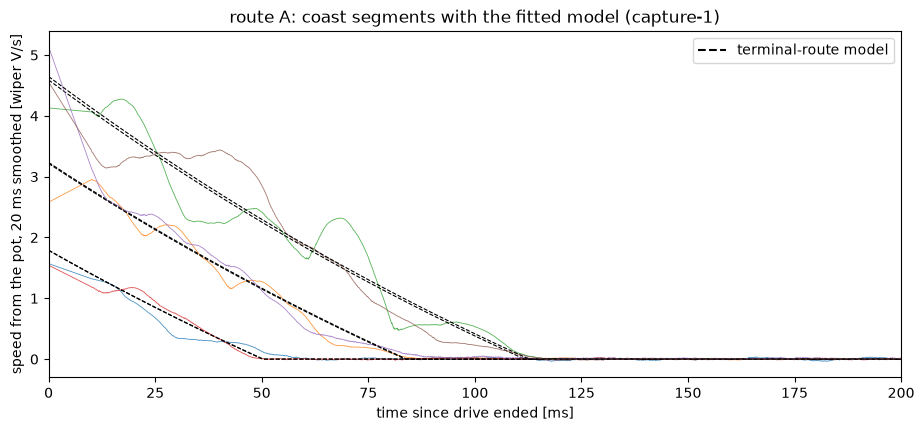

,EMF slope [V per wiper V/s],a [wiper V/s2],b [1/s],b se [1/s],a/b [wiper V/s],rms resid [mV],entry speed min [wiper V/s],entry speed max [wiper V/s]
mean,0.276,31.349,4.436,0.067,7.076,30.527,1.708,4.549
min,0.271,30.678,4.224,0.066,6.703,30.166,1.627,4.500
max,0.278,31.985,4.577,0.068,7.571,31.074,1.787,4.647


In [10]:
FIT_N = 5000    # 250 ms of every coast segment enters the fit
SG_WIN = 401    # 20 ms smoothing window for speed from the pot
COAST_SKIP = 3  # samples excluded at the start of every coast segment

spin_rails = {n: rail_V(df, 20, 40) for n, (df, _) in spin.items()}

def coast_segments(df):
    # Per coast segment: position and EMF vA - vB positive along the entry
    # direction, the terminal sum for the diode-phase mask, all in V.
    out = []
    for seg_id, seg in df[df["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb, vb_b = seg["vb"].iloc[0], seg["vb_b"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb_b)
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(df.loc[df["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * CH.v_adc_per_count,
            "e": (vA - vB) * d,
            "sum": vA + vB,
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= COAST_SKIP) & (c["sum"] < rail)

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def terminal_fit(segs, rail):
    # Shared (a, b) in EMF units, one entry value per segment.
    t = np.arange(FIT_N) / TICK_HZ
    masks = [coast_mask(c, rail)[:FIT_N] for c in segs]
    def resid(x):
        return np.concatenate([(speed_model(t, x[2 + i], x[0], x[1]) - c["e"][:FIT_N])[m]
                               for i, (c, m) in enumerate(zip(segs, masks))])
    x0 = [30.0, 5.0] + [max(c["e"][COAST_SKIP], 0.1) for c in segs]
    lb = [0.0, 0.0] + [0.0] * len(segs)
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"a": res.x[0], "b": res.x[1], "b_se": np.sqrt(cov[1, 1]), "starts": res.x[2:],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

def terminal_slope(segs, rail):
    # EMF integral over the segment divided by the travel: V per wiper V/s.
    ratios = []
    for c in segs:
        m = coast_mask(c, rail)
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:COAST_SKIP])
        ratios.append(np.sum(c["e"][m]) / TICK_HZ / travel)
    return np.mean(ratios)

coast_fits = {}
for name, (df, _) in spin.items():
    segs = coast_segments(df)
    slope = terminal_slope(segs, spin_rails[name])
    f = terminal_fit(segs, spin_rails[name])
    coast_fits[name] = {"segs": segs, "slope": slope, "a": f["a"] / slope, "b": f["b"],
                        "b_se": f["b_se"], "starts": f["starts"] / slope,
                        "rms_resid": f["rms_resid"]}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["starts"][i], f["a"], f["b"]), "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 200)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"route A: coast segments with the fitted model ({name})")
ax.legend()
plt.show()

route_a = pd.DataFrame([{
    "recording": n, "EMF slope [V per wiper V/s]": f["slope"],
    "a [wiper V/s2]": f["a"], "b [1/s]": f["b"], "b se [1/s]": f["b_se"],
    "a/b [wiper V/s]": f["a"] / f["b"], "rms resid [mV]": f["rms_resid"] * 1e3,
    "entry speed min [wiper V/s]": f["starts"].min(), "entry speed max [wiper V/s]": f["starts"].max(),
} for n, f in coast_fits.items()]).set_index("recording")
route_a.agg(["mean", "min", "max"]).round(3)

In [11]:
# The same fit per direction, with the recording's EMF slope.
rows = []
for name, f in coast_fits.items():
    for d, label in [(1, "forward"), (-1, "reverse")]:
        segs = [c for c in f["segs"] if c["dir"] == d]
        ff = terminal_fit(segs, spin_rails[name])
        rows.append({"direction": label, "recording": name,
                     "a [wiper V/s2]": ff["a"] / f["slope"], "b [1/s]": ff["b"],
                     "a/b [wiper V/s]": ff["a"] / f["slope"] / ff["b"]})
route_a_dir = pd.DataFrame(rows).groupby("direction")[["a [wiper V/s2]", "b [1/s]", "a/b [wiper V/s]"]]
route_a_dir.agg(["mean", "min", "max"]).round(3)

a [wiper V/s2]                 b [1/s]                \
                    mean     min     max    mean    min    max   
direction                                                        
forward           32.471  31.498  33.208   4.241  3.833  4.568   
reverse           29.976  28.588  31.486   4.744  4.114  5.477   

          a/b [wiper V/s]                
                     mean    min    max  
direction                                
forward             7.714  6.895  8.663  
reverse             6.404  5.220  7.653

Findings:

- The EMF slope is 0.276 V per wiper V/s (0.271 to 0.278), the Coulomb
  term 31.3 wiper V/s$^2$ (30.7 to 32.0) and the viscous term 4.44 1/s
  (4.22 to 4.58), the values of notebook 01 on this chain. The ratio
  $a / b$ is 7.08 wiper V/s with a spread of 6.70 to 7.57 across the five
  recordings. The battery run gave 34.4, 3.00 and 11.5. The Coulomb term
  came down 9% and the viscous term went up 48%, so the crossover speed
  moved down by a third.
- Per direction, $a$ is 32.5 forward and 30.0 reverse and $b$ is 4.24 and
  4.74, an asymmetry of 8% in $a$ and 11% in $b$ of opposite sign, so the
  ratio is 7.71 forward and 6.40 reverse with overlapping spreads.
- The coast entry speeds are 1.6 to 4.6 wiper V/s, so route A is fitted
  below 5.0 wiper V/s and says nothing above it. The ratio $a / b$ lies
  above the fitted range again, so at the top of the range the viscous
  term is two thirds of the Coulomb term, and the split between the two
  rests on the curvature within the range. The range is half as wide as
  the battery run's, which makes that split the weaker for it.

## 7. Agreement of the two routes

The ratio $\tau_c / b_v$ is the speed at which viscous friction equals
Coulomb friction. Route A gives it as $a / b$ and route B as $i_c / i_v$,
with no inertia or torque constant involved. The table sets the two side
by side, route B in the matched speed range with the extrapolated steady
values (section 6.1), and the extended range and the reference-window
values for comparison.

In [12]:
ra = route_a["a/b [wiper V/s]"]
rows = [{"route": "A, coast", "direction": "both", "ratio [wiper V/s]": ra.mean(),
         "min": ra.min(), "max": ra.max(), "vs route A [%]": 0.0}]
for method, rname in [("extrapolated steady state", f"matched, <= {V_MATCH}"),
                      ("extrapolated steady state", f"extended, <= {V_EXT}"),
                      ("reference window, last 60%", f"matched, <= {V_MATCH}")]:
    for direction in ["forward", "reverse"]:
        f = route_b.loc[(method, rname, direction)]
        rows.append({"route": f"B, drive, {method}, {rname}", "direction": direction,
                     "ratio [wiper V/s]": f["ratio [wiper V/s]"], "min": f["ratio min"],
                     "max": f["ratio max"],
                     "vs route A [%]": (f["ratio [wiper V/s]"] / ra.mean() - 1) * 100})
agree = pd.DataFrame(rows).set_index(["route", "direction"])
agree.round(2)


ratio [wiper V/s]  \
route                                              direction                      
A, coast                                           both                    7.08   
B, drive, extrapolated steady state, matched, <... forward                 4.20   
                                                   reverse                 5.46   
B, drive, extrapolated steady state, extended, ... forward                 5.25   
                                                   reverse                 6.09   
B, drive, reference window, last 60%, matched, ... forward                 1.97   
                                                   reverse                 2.65   

                                                               min   max  \
route                                              direction               
A, coast                                           both       6.70  7.57   
B, drive, extrapolated steady state, matched, <... forward    2.39  5.71   
                                                   reverse    3.36  7.05   
B, drive, extrapolated steady state, extended, ... forward    3.14  6.56   
                                                   reverse    4.42  7.46   
B, drive, reference window, last 60%, matched, ... forward    1.05  2.68   
                                                   reverse    1.46  3.14   

                                                              vs route A [%]  
route                                              direction                  
A, coast                                           both                 0.00  
B, drive, extrapolated steady state, matched, <... forward            -40.67  
                                                   reverse            -22.83  
B, drive, extrapolated steady state, extended, ... forward            -25.79  
                                                   reverse            -13.87  
B, drive, reference window, last 60%, matched, ... forward            -72.20  
                                                   reverse            -62.57

In [13]:
# The friction constants in both unit systems (route B in the matched range,
# extrapolated steady state).
fb = route_b.sort_index().loc[("extrapolated steady state", f"matched, <= {V_MATCH}")]
consts = pd.DataFrame([
    {"term": "Coulomb", "route A, mechanical": route_a["a [wiper V/s2]"].mean(), "unit A": "wiper V/s2",
     "route B forward": fb.loc["forward", "i_c [A]"], "route B reverse": fb.loc["reverse", "i_c [A]"], "unit B": "A"},
    {"term": "viscous", "route A, mechanical": route_a["b [1/s]"].mean(), "unit A": "1/s",
     "route B forward": fb.loc["forward", "i_v [A per wiper V/s]"], "route B reverse": fb.loc["reverse", "i_v [A per wiper V/s]"],
     "unit B": "A per wiper V/s"},
    {"term": "Coulomb / viscous", "route A, mechanical": ra.mean(), "unit A": "wiper V/s",
     "route B forward": fb.loc["forward", "ratio [wiper V/s]"], "route B reverse": fb.loc["reverse", "ratio [wiper V/s]"],
     "unit B": "wiper V/s"},
]).set_index("term")
# If one (tau_c, b_v) stood behind both routes, A / B would be Kt / J for both terms.
consts["A / B forward"] = consts["route A, mechanical"] / consts["route B forward"]
consts["A / B reverse"] = consts["route A, mechanical"] / consts["route B reverse"]
consts.round(4)


,"route A, mechanical",unit A,route B forward,route B reverse,unit B,A / B forward,A / B reverse
term,,,,,,,
Coulomb,31.3487,wiper V/s2,0.0323,0.0334,A,970.4748,937.8930
viscous,4.4357,1/s,0.0077,0.0061,A per wiper V/s,576.5066,724.7205
Coulomb / viscous,7.0763,wiper V/s,4.1983,5.4610,wiper V/s,1.6855,1.2958


Verdict:

- The two routes still do not agree, and the open question of the last
  loop comes back a smaller yes. Route A gives 7.08 wiper V/s with a
  spread of 6.70 to 7.57. Route B in the matched range gives 4.20 forward
  and 5.46 reverse, 41% and 23% below route A, where the battery session
  had both directions 48 to 49% below. The gap closed on the reverse side
  and stayed wide on the forward side, so the factor of two became a
  factor of 1.7 forward and 1.3 reverse.
- The gap is now clearly a function of the fit range. Extending route B to
  7.0 wiper V/s leaves it 26% and 14% below, and the full-range line lands
  20% and 31% *above* route A. Route A's own range is half what it was, so
  the two routes now overlap over a narrower band of speed than before,
  and neither has a wide enough range to pin its own split.
- Route B still sees relatively more viscous friction than route A over
  the matched range. If the same $\tau_c$ and $b_v$ stood behind both, the
  ratios $a / i_c$ and $b / i_v$ would both equal $K_t / J$. They are 970
  and 577 wiper V/s$^2$ per A forward and 938 and 725 reverse. On the
  battery those were 890 and 450 forward, 1000 and 520 reverse, so the
  Coulomb pair barely moved and the viscous pair closed by a third.
- Route A reproduces the approach to rest of section 8.1 within 2% by the
  EMF, so route A stands as the friction measurement of this notebook and
  route B is provisional, as before.
- *Hypothesis (not tested here): the drive current at speed carries a term
  besides friction. Route B assumes the crest-scan sample is the
  period-average winding current and that the average current times a
  constant $K_t$ is the friction torque. At speed the drive current is the
  small difference between the applied voltage and the back-EMF, and any
  speed-dependent drop in the winding, the brushes or the switches that is
  absent at stall appears in it as a term proportional to speed, which is
  what raises $i_v$. Notebook 03 measures the back-EMF constant and the
  winding resistance from these same recordings and can predict the steady
  current at every grid point from speed alone. Where that prediction
  meets the measured current, route B can be read as friction.*
- *Hypothesis (not tested here): the route A split between $a$ and $b$ is
  biased by the EMF ripple, and worse than before. The ratio lies above
  the fitted speed range, so $b$ rests on the curvature of a decay that
  the EMF ripple blurs, and this session's coasts start at half the speed.
  The standard error of 0.07 1/s on $b$ takes the residual as
  uncorrelated and understates this. A coast from a higher speed would pin
  $b$ directly and needs either a stronger supply or a longer runway than
  the spin-down series has.*

## 8. Near rest and position dependence

### 8.1 The approach to rest

Notebook 01 asked whether friction near rest falls below the fitted
Coulomb term. The coast segments hold the answer in their last tens of
milliseconds, and two signals are available there, the pot speed and the
EMF. The pot ripple prevents a per-segment answer (a segment covers a
fraction of one ripple period in that window), so the thirty coast
segments are pooled. Each segment's rest instant is the first sample after
which the 20 ms smoothed pot speed stays below 0.1 wiper V/s (the filter's
half window at the segment end is excluded from the search), the segments
are aligned on that instant, and both speeds are averaged across segments
in 5 ms bins over the last 80 ms. The EMF is smoothed with the same 20 ms
window and converted with the recording's EMF slope. The model's approach
to rest under $(a, b)$ from section 6.2 is

$$v(t) = \frac{a}{b}\left(e^{-b\,(t - t_{rest})} - 1\right), \qquad t < t_{rest},$$

which is drawn over the pooled traces. The deceleration of each pooled
trace over two windows (45 to 15 ms and 25 to 5 ms before rest) is
compared with the model's over the same windows, and the pooled distance
to rest over the last 40 ms is fitted with a parabola, $d = a_{40}\,t^2 /
2$, for a third estimate that uses the position alone.

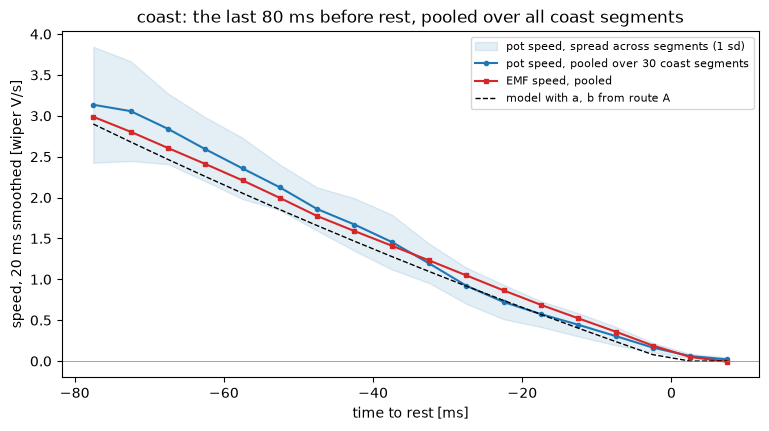

,v_pot,v_pot_sd,v_emf,v_emf_sd,dist_mV,v_pot_fwd,v_emf_fwd,v_pot_rev,v_emf_rev,v_model,dist_model_mV
bin center [ms to rest],,,,,,,,,,,
-77.5,3.135,0.710,2.988,0.130,119.396,2.608,2.983,3.706,2.993,2.899,105.927
-72.5,3.057,0.610,2.805,0.107,105.163,2.566,2.810,3.549,2.800,2.681,91.978
-67.5,2.841,0.432,2.607,0.104,89.927,2.511,2.613,3.170,2.600,2.467,79.111
-62.5,2.592,0.391,2.411,0.102,76.619,2.372,2.412,2.813,2.410,2.258,67.301
-57.5,2.357,0.374,2.210,0.110,64.436,2.174,2.200,2.540,2.221,2.053,56.525
-52.5,2.125,0.278,1.996,0.122,52.470,2.015,1.987,2.233,2.005,1.853,46.761
-47.5,1.860,0.264,1.774,0.120,41.576,1.810,1.762,1.910,1.786,1.658,37.986
-42.5,1.670,0.321,1.591,0.101,33.615,1.756,1.579,1.590,1.602,1.466,30.178
-37.5,1.457,0.335,1.411,0.105,25.450,1.542,1.398,1.375,1.424,1.279,23.317


In [14]:
A_COAST, B_COAST = route_a["a [wiper V/s2]"].mean(), route_a["b [1/s]"].mean()
REST_VPS = 0.1
HALF_WIN = SG_WIN // 2

traces = []
for name, f in coast_fits.items():
    for c in f["segs"]:
        p = c["p"]
        v = savgol_filter(p, SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        e = np.where(coast_mask(c, spin_rails[name]), c["e"], 0.0)
        ve = savgol_filter(e, SG_WIN, 2) / f["slope"]
        t_rest = np.where(v[:-HALF_WIN] > REST_VPS)[0][-1] + 1
        p_rest = np.median(p[-1000:])
        tt = (np.arange(len(p)) - t_rest) / TICK_HZ * 1e3
        traces.append(pd.DataFrame({"dir": c["dir"], "t_ms": tt, "v_pot": v, "v_emf": ve,
                                    "dist": p_rest - p}))
tr = pd.concat(traces)
tr = tr[(tr["t_ms"] >= -80) & (tr["t_ms"] < 10)].copy()
tr["bin_ms"] = (tr["t_ms"] // 5) * 5
pooled = tr.groupby("bin_ms").agg(v_pot=("v_pot", "mean"), v_pot_sd=("v_pot", "std"),
                                  v_emf=("v_emf", "mean"), v_emf_sd=("v_emf", "std"),
                                  dist_mV=("dist", "mean"))
pooled["dist_mV"] *= 1e3
for d, label in [(1, "fwd"), (-1, "rev")]:
    g = tr[tr["dir"] == d].groupby("bin_ms")
    pooled[f"v_pot_{label}"] = g["v_pot"].mean()
    pooled[f"v_emf_{label}"] = g["v_emf"].mean()
tm = pooled.index.to_numpy() + 2.5
tp = np.maximum(-tm, 0) / 1e3     # time to rest, s
pooled["v_model"] = A_COAST / B_COAST * (np.exp(B_COAST * tp) - 1)
pooled["dist_model_mV"] = (A_COAST / B_COAST ** 2 * (np.exp(B_COAST * tp) - 1) - A_COAST / B_COAST * tp) * 1e3
pooled.index = tm
pooled.index.name = "bin center [ms to rest]"

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(tm, pooled["v_pot"] - pooled["v_pot_sd"], pooled["v_pot"] + pooled["v_pot_sd"],
                color="tab:blue", alpha=0.12, label="pot speed, spread across segments (1 sd)")
ax.plot(tm, pooled["v_pot"], "-o", ms=3, color="tab:blue", label="pot speed, pooled over 30 coast segments")
ax.plot(tm, pooled["v_emf"], "-s", ms=3, color="tab:red", label="EMF speed, pooled")
ax.plot(tm, pooled["v_model"], "k--", lw=1, label="model with a, b from route A")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("time to rest [ms]")
ax.set_ylabel("speed, 20 ms smoothed [wiper V/s]")
ax.set_title("coast: the last 80 ms before rest, pooled over all coast segments")
ax.legend(fontsize=8)
plt.show()

pooled.round(3)

In [15]:
def decel(series, lo, hi):
    m = (series.index >= lo) & (series.index <= hi)
    return -np.polyfit(series.index[m] / 1e3, series[m], 1)[0]

def parabola_a(series, lo):
    m = (series.index >= lo) & (series.index < 0)
    t2 = (series.index[m] / 1e3) ** 2
    return 2 * np.polyfit(t2, series[m] / 1e3, 1)[0]

rows = []
for lo, hi in [(-45, -15), (-25, -5)]:
    rows.append({"quantity": f"deceleration, {-lo} to {-hi} ms before rest [wiper V/s2]",
                 "pot, pooled": decel(pooled["v_pot"], lo, hi),
                 "pot, forward": decel(pooled["v_pot_fwd"], lo, hi),
                 "pot, reverse": decel(pooled["v_pot_rev"], lo, hi),
                 "EMF, pooled": decel(pooled["v_emf"], lo, hi),
                 "EMF, forward": decel(pooled["v_emf_fwd"], lo, hi),
                 "EMF, reverse": decel(pooled["v_emf_rev"], lo, hi),
                 "model": decel(pooled["v_model"], lo, hi)})
rows.append({"quantity": "parabola a over the last 40 ms of distance to rest [wiper V/s2]",
             "pot, pooled": parabola_a(pooled["dist_mV"], -40),
             "model": parabola_a(pooled["dist_model_mV"], -40)})
rows.append({"quantity": "Coulomb term a from route A [wiper V/s2]", "model": A_COAST})
near_tab = pd.DataFrame(rows).set_index("quantity").round(1)
near_tab

,"pot, pooled","pot, forward","pot, reverse","EMF, pooled","EMF, forward","EMF, reverse",model
quantity,,,,,,,
"deceleration, 45 to 15 ms before rest [wiper V/s2]",45.5,50.8,40.3,36.2,36.8,35.6,35.8
"deceleration, 25 to 5 ms before rest [wiper V/s2]",27.6,22.3,32.8,33.5,34.2,32.9,33.5
parabola a over the last 40 ms of distance to rest [wiper V/s2],34.0,NaN,NaN,NaN,NaN,NaN,33.1
Coulomb term a from route A [wiper V/s2],NaN,NaN,NaN,NaN,NaN,NaN,31.3


Findings:

- By the EMF the pooled deceleration is 36.2 wiper V/s$^2$ over 45 to
  15 ms before rest and 33.5 over 25 to 5 ms, against the model's 35.8 and
  33.5, so the rate of slowing agrees with the route A model within 1%
  pooled and within 3% in either direction on its own. There is no plateau before rest and
  no abrupt stop from a finite speed, so the mechanism glides to rest
  under the same Coulomb term the fit found at speed, and no separate
  near-rest term is needed.
- The pooled EMF speed sits above the model, by 3% at 80 ms before rest
  and growing to 21% at 17 ms and more inside 10 ms. A constant offset of
  about 3 ms in the alignment reproduces that shape, and the alignment is
  the pot's rest instant through a 20 ms smoothing filter, so I read it as
  the alignment and not as a friction term. On the battery run the same
  comparison held within 3% at every bin, so this is one number that got
  worse this session, and the halved speeds are the reason the alignment
  matters more.
- By the pot the pooled deceleration is 45.5 over 45 to 15 ms and 27.6
  over 25 to 5 ms, and the two directions split by 10 wiper V/s$^2$ in the
  first window. The pooled distance to rest over the last 40 ms gives a
  Coulomb term of 34.0 against the model's 33.1, so the position itself
  agrees with the model within 3% and the scatter sits in the pot-derived
  speed. *Hypothesis (not tested here): the pot ripple does not average
  out in this pool, since every coast of a given entry duty comes to rest
  near the same position and the ripple phases across recordings are
  therefore correlated, which the split between the forward and reverse
  pot traces against the EMF traces supports.*

### 8.2 Position dependence

The matched-range grid steps end at 0.7 to 0.9 wiper V forward and 2.3
to 2.5 wiper V reverse. The figure plots the residual of every
matched-range route B step from its direction's line (section 6.1)
against the step's position, and the table bins it by position and by
duty. One limit needs stating first. Every step of a given duty starts
from the same repositioned end and reaches the same position, so
position, duty, speed and time into the sweep are confounded by design. A
residual that varies with position cannot be separated from a departure
of the current from the linear speed model. The bins are shown for what
they are.

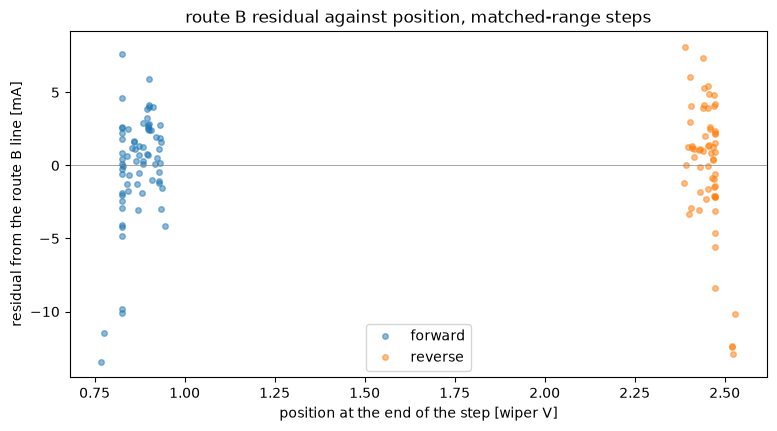

residual_mA  sd_mA  steps  duty_pct  \
direction position bin [wiper V]                                        
forward   0.7                          -12.46   1.38      2     15.00   
          0.8                            0.03   3.18     48     25.62   
          0.9                            1.07   2.49     22     42.73   
reverse   2.3                            2.05   4.17      4     41.25   
          2.4                            0.72   3.11     55     28.27   
          2.5                          -11.96   1.22      4     16.25   

                                  speed_Vps  
direction position bin [wiper V]             
forward   0.7                          2.16  
          0.8                          2.05  
          0.9                          3.99  
reverse   2.3                          4.57  
          2.4                          2.41  
          2.5                          2.51

In [16]:
rows = []
for d, label in [(1, "forward"), (-1, "reverse")]:
    f = route_b.loc[("extrapolated steady state", f"matched, <= {V_MATCH}", label)]
    g = grid_tab[(grid_tab["dir"] == d) & (grid_tab["v_ss_Vps"] <= V_MATCH)].copy()
    g["residual_mA"] = (g["i_ss_A"] - f["i_c [A]"] - f["i_v [A per wiper V/s]"] * g["v_ss_Vps"]) * 1e3
    g["direction"] = label
    rows.append(g)
res = pd.concat(rows)
res["position bin [wiper V]"] = (res["pos_V"] // 0.1) * 0.1

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, color in [("forward", "tab:blue"), ("reverse", "tab:orange")]:
    g = res[res["direction"] == label]
    ax.plot(g["pos_V"], g["residual_mA"], "o", ms=4, alpha=0.5, color=color, label=label)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("position at the end of the step [wiper V]")
ax.set_ylabel("residual from the route B line [mA]")
ax.set_title("route B residual against position, matched-range steps")
ax.legend()
plt.show()

by_pos = (res.groupby(["direction", "position bin [wiper V]"])
          .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
               steps=("residual_mA", "size"), duty_pct=("mag_pct", "mean"), speed_Vps=("v_ss_Vps", "mean")))
by_pos.round(2)

In [17]:
# The same residuals binned by duty, which is the other axis of the confound.
(res.groupby(["direction", "mag_pct"])
    .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
         steps=("residual_mA", "size"), speed_Vps=("v_ss_Vps", "mean"))
    .round(2))

residual_mA  sd_mA  steps  speed_Vps
direction mag_pct                                      
forward   15             -2.88   7.67     10       0.81
          20             -0.78   2.27     10       1.36
          25             -0.56   2.32     10       2.20
          30              0.51   1.67     10       2.75
          35              1.75   1.66     10       3.04
          40              2.22   2.21     10       3.57
          45              0.32   1.78     10       4.32
          50             -2.82   1.83      2       4.97
reverse   15             -3.12   6.95     10       1.04
          20             -2.15   4.87     10       1.63
          25              0.56   2.28     10       1.85
          30              1.52   2.51     10       2.59
          35              1.70   3.02     10       3.31
          40             -0.23   2.37     10       4.25
          45              5.71   2.59      3       4.78

Findings:

- The bins that hold 22 to 55 steps sit within 2 mA of zero, against a
  steady current of 35 to 70 mA. The bins at the edges of travel are the
  thin ones. Forward 0.7 wiper V holds two steps at -12.5 mA and reverse
  2.5 wiper V holds four at -12.0 mA, and both are made of the 15% duty
  steps, the slowest and the noisiest.
- Binned by duty the residuals lie within 3 mA of zero from 20% to 40%,
  with a scatter of 2 to 3 mA within each bin. The 15% point sits 3 mA low
  with a scatter of 7 to 8 mA, several times any other bin, which is where
  the two thin position bins come from. The matched range is narrow enough
  now that the 45% and 50% points hold only 2 or 3 steps each, and the
  reverse 45% point reads 6 mA high on three of them.
- Within the matched range friction shows no position dependence that this
  design can resolve, except at the 15% grid point where the estimate
  itself is worst. A test that separates position from speed needs steps
  of one duty started from several positions, which none of the three
  series provides.

## 9. Limitations and open issues

- **The board is a hacked rig.** The bus telemetry stream couples into the
  current amplifier output on this board (section 1). It is flat at rest
  on this firmware build, but a few counts is a few milliamps, and route
  B's line lives between 35 and 100 mA, so a few percent of $i_c$ is
  within reach of it. This is a limitation of this board, not something I
  code around.
- **One unit, one supply.** All numbers describe this one servo on a
  laptop USB port that sags under load. The gear train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal rest
  readings are measured per recording and remove themselves from the EMF.
- **The onset scatters across recordings.** The band is 9% to 15% duty,
  and recordings 4 and 5 sat still up to 14% where recording 1 broke away
  at 9% (section 5.1). The ladder is 1% fine, so the width is the
  mechanism and the session, not the grid. Whether it is warm-up or wear
  is open.
- **The breakaway current is model-derived** from notebook 03's
  resistance, which is itself being re-measured on this chain, so I carry
  its 4.3 to 4.8 Ohm bracket (section 5.3). The ramp's settled rungs at
  14 to 18% give a measured current just above breakaway for the first
  time, but not at the onset.
- **The grid steps are short.** The steady current and speed are
  extrapolated with a fitted exponential (section 6.1). The transient left
  in the reference window is much smaller on this chain than on the
  battery, and the falling extrapolated current above 12 wiper V/s went
  away with it.
- **Route B is provisional.** The two routes disagree by a factor of 1.7
  forward and 1.3 reverse in the ratio of Coulomb to viscous friction
  (section 7), and the size of the disagreement depends on the fit range.
  The electrical model of notebook 03 is needed before route B can be read
  as friction.
- **Route A's split is range-limited, and more so than before.** The coast
  entries reach 4.6 wiper V/s and the fitted crossover lies at 7.08, so
  $b$ rests on the curvature within the range and the EMF ripple limits
  it. The USB supply halved that range.
- **The pot ripple** limits every per-segment or per-step speed estimate
  at low speed, and it does not average out of a pool whose segments rest
  at correlated positions (section 8.1). The EMF and the extrapolated
  estimates avoid it, the per-step pot estimates do not.
- **Position, speed and duty are confounded** in the grid (section 8.2),
  and the matched range is now narrow enough that two position bins hold
  four steps or fewer.

## 10. What the next notebooks use from here

- The breakaway band of 0.41 to 0.68 V, the same in both directions
  (section 5.2), as the dead zone any open-loop voltage command has to
  cross, and the model-derived breakaway current of 0.091 to 0.152 A with
  notebook 03's 4.5 Ohm.
- The friction constants of route A, Coulomb 31.3 wiper V/s$^2$ and
  viscous 4.44 1/s with a crossover at 7.08 wiper V/s (section 6.2), as
  the friction terms of the plant model. The approach to rest follows them
  with no separate near-rest term (section 8.1).
- The route B lines of section 6.1, $i_c$ of 0.0323 and 0.0334 A and $i_v$
  of 0.0077 and 0.0061 A per wiper V/s forward and reverse in the matched
  range, as the measured steady current at every grid point, for notebook
  03 to compare with its prediction from speed, resistance and back-EMF
  constant. The difference is the term of the drive current that this
  notebook could not separate from friction.
- The drive time constant of 18 to 25 ms (section 6.1), which the inertia
  notebook combines with the coast damping of 4.44 1/s and the brake
  damping of notebook 01 to separate inertia from the electrical damping.
- The settled ramp current of 35 to 40 mA at 14 to 18% duty, just above
  breakaway, which is a friction current the old chain could not reach.
- The EMF as the near-rest speed signal of choice, since the pooled pot
  speed carries a correlated ripple residue that the EMF does not
  (section 8.1).
- The fact that the grid confounds position with speed, so that a
  position-dependence test needs a dedicated series.